In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(12345)

In [54]:
def count_outliers(data):
    """Возвращает количество выбросов по правилу Тьюки"""
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outliers = data[(data < lower) | (data > upper)]
    return len(outliers)

In [56]:
sample_sizes = [20, 100]
n_iterations = 1000

# Теоретические доли выбросов для каждого распределения
theoretical_outliers = {
    'Нормальное N(0,1)': 0.007,      # 0.7% для нормального
    'Коши C(0,1)': 0.15,              # 15% для Коши (тяжелые хвосты)
    'Лапласа L(0, 1/sqrt(2))': 0.065,       # 6.5% для Лапласа
    'Пуассона P(5)': 0.015,            # 1.5% для Пуассона с 5
    'Равномерное U(-sqrt(3),sqrt(3))': 0.00      # 0% для равномерного
}

distributions = {
    'Нормальное N(0,1)': lambda n: np.random.normal(0, 1, n),
    'Коши C(0,1)': lambda n: np.random.standard_cauchy(n),
    'Лапласа L(0, 1/sqrt(2))': lambda n: np.random.laplace(0, 1/np.sqrt(2), n),
    'Пуассона P(5)': lambda n: np.random.poisson(5, n),
    'Равномерное U(-sqrt(3),sqrt(3))': lambda n: np.random.uniform(-np.sqrt(3), np.sqrt(3), n)
}

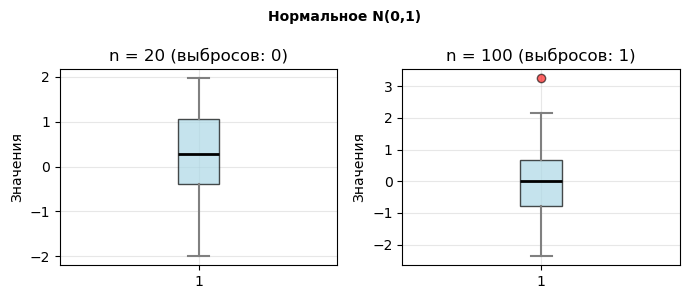

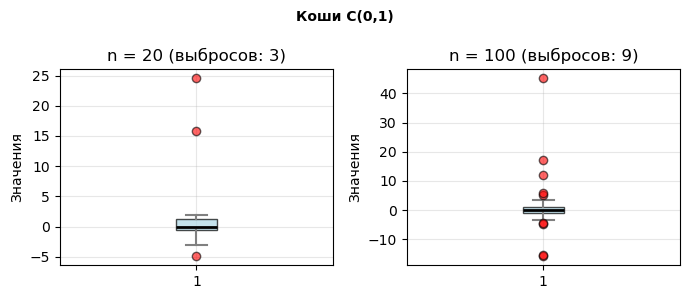

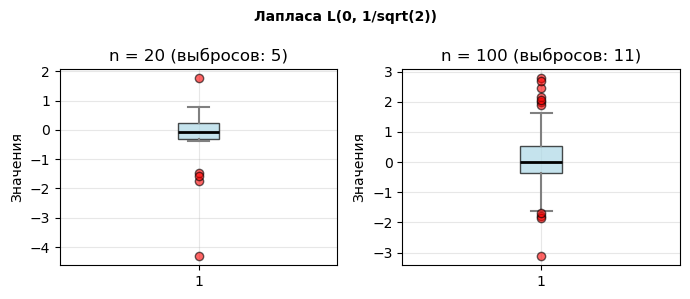

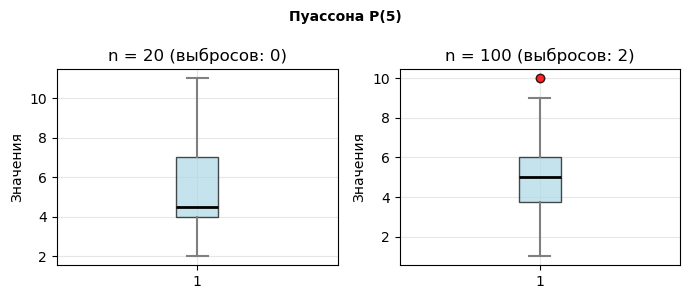

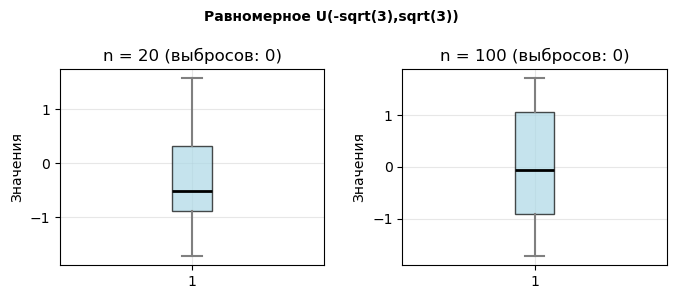

In [58]:
for dist_name, generator in distributions.items():
    fig, axes = plt.subplots(1, 2, figsize=(7, 3))
    fig.suptitle(f'{dist_name}', fontsize=10, fontweight='bold')
    
    for idx, n in enumerate([20, 100]):
        sample = generator(n)

        bp = axes[idx].boxplot(sample, vert=True, patch_artist=True,
                               medianprops={'color': 'black', 'linewidth': 2},
                               whiskerprops={'color': 'gray', 'linewidth': 1.5},
                               capprops={'color': 'gray', 'linewidth': 1.5},
                               flierprops={'marker': 'o', 'markerfacecolor': 'red', 
                                          'markersize': 6, 'alpha': 0.6})

        bp['boxes'][0].set_facecolor('lightblue')
        bp['boxes'][0].set_alpha(0.7)

        n_outliers = count_outliers(sample)
        
        axes[idx].set_title(f'n = {n} (выбросов: {n_outliers})')
        axes[idx].set_ylabel('Значения')
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [59]:
print('СРЕДНЯЯ ДОЛЯ ВЫБРОСОВ (1000 экспериментов)')
print(f"{'Распределение':<30} {'n=20':>10} {'n=100':>10} {'Теоретическая':>15}")
print('-'*52)

for name, gen in distributions.items():
    fractions_20 = []
    fractions_100 = []
    
    for _ in range(n_iterations):
        fractions_20.append(count_outliers(gen(20)) / 20)
        fractions_100.append(count_outliers(gen(100)) / 100)
    
    mean_20 = np.mean(fractions_20)
    mean_100 = np.mean(fractions_100)
    theor = theoretical_outliers[name]
    
    print(f"{name:<30} {mean_20:>10.4f} {mean_100:>10.4f} {theor:>15.3f}")

СРЕДНЯЯ ДОЛЯ ВЫБРОСОВ (1000 экспериментов)
Распределение                        n=20      n=100   Теоретическая
----------------------------------------------------
Нормальное N(0,1)                  0.0228     0.0110           0.007
Коши C(0,1)                        0.1539     0.1565           0.150
Лапласа L(0, 1/sqrt(2))            0.0760     0.0663           0.065
Пуассона P(5)                      0.0229     0.0144           0.015
Равномерное U(-sqrt(3),sqrt(3))     0.0023     0.0000           0.000
